# Sentiment Classification -- Marketing Channel Performance
**Thesis:** Which marketing channels acquire the worst sellers, causing logistical delays and destroying customer sentiment?

| Phase | Description |
|:------|:------------|
| **Integrity Audit** | Drop null scores, cap outlier delays |
| **Target** | Binary `is_bad_review` (score <= 2) |
| **NLP** | Portuguese text cleaning + TF-IDF top 20 negative keywords |
| **Imbalance** | SMOTE on training data only |
| **Models** | Random Forest, XGBoost, Deep Learning -- Optuna tuned |
| **Interpretability** | Feature importance + SHAP |
| **Export** | Final curated CSV for Tableau |

In [2]:
# Install dependencies
import subprocess, sys
for pkg in ["numpy<2", "imbalanced-learn", "xgboost", "lightgbm", "optuna", "shap", "nltk"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

In [3]:
# Imports & Configuration
import warnings; warnings.filterwarnings("ignore")
import re, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
import nltk
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score)
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb
import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap

sns.set_theme(style="darkgrid", palette="viridis")
plt.rcParams.update({"figure.figsize": (12, 5), "figure.dpi": 120})
SEED = 42; np.random.seed(SEED)

print("All imports loaded.")


All imports loaded.


---
## 1. Data Ingestion & Integrity Audit
> *If our thesis is about sentiment, analyzing an order with no sentiment is useless.*

In [4]:
# Load data
df_raw = pd.read_csv("Dataset/vw_seller_order_performance.csv")
print(f"Raw shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"\nColumns: {list(df_raw.columns)}")
df_raw.head()

Raw shape: 4,980 rows x 10 columns

Columns: ['mql_id', 'marketing_channel', 'seller_id', 'business_segment', 'total_items_sold', 'total_order_revenue', 'order_id', 'logistical_delay_days', 'final_review_score', 'review_message']


,mql_id,marketing_channel,seller_id,business_segment,total_items_sold,total_order_revenue,order_id,logistical_delay_days,final_review_score,review_message
0,cfccca319397a5ea2bb11bd90b0d925d,paid_search,ba143b05f0110f0dc71ad71b4466ce92,books,1.0,53.99,0005f50442cb953dcd1d21e1fb923495,-18.0,4.0,NaN
1,115f08592f4c2bb29013efbbc46608fc,unknown,ffc470761de7d0232558ba5e786e57b7,construction_tools_house_garden,1.0,54.00,001ac194d4a326a6fa99b581e9a3d963,-4.0,5.0,Entregaram do prazo
2,31aa9651503a33c7f28f2a6e4d46b6e0,unknown,d3dcf0604eabf0224fbd5948b5e02f69,music_instruments,1.0,94.90,0029f17cf0e7640c5cb6825af681303f,-11.0,5.0,NaN
3,fc4166d1b1e192f650ee2d807b54c943,social,70c27847eca8195c983ed7e798c56743,pet,1.0,168.80,00335f75ea6a4455b524a8dd177067f5,-24.0,5.0,NaN
4,e0bcbf50b9afa71ee130b94dfe8bcf2e,paid_search,516e7738bd8f735ac19a010ee5450d8d,health_beauty,1.0,48.90,00345f338696283410b7977d2e3efc89,-11.0,5.0,NaN


In [5]:
# -- Integrity Check 1: Null Analysis --
print("== Missing Values ==")
null_pct = (df_raw.isnull().sum() / len(df_raw) * 100).round(1)
for col, pct in null_pct.items():
    flag = " << DROP THESE" if col == "final_review_score" and pct > 0 else ""
    print(f"  {col:<30} {pct:>6.1f}%{flag}")

# Drop rows without review scores (no sentiment = useless for classification)
df = df_raw.dropna(subset=["final_review_score"]).copy()
print(f"\nRows after dropping null scores: {len(df):,} (dropped {len(df_raw)-len(df):,})")

== Missing Values ==
  mql_id                            0.0%
  marketing_channel                 0.4%
  seller_id                         0.0%
  business_segment                  0.0%
  total_items_sold                  9.3%
  total_order_revenue               9.3%
  order_id                          9.3%
  logistical_delay_days            10.4%
  final_review_score                9.8% << DROP THESE
  review_message                   66.0%

Rows after dropping null scores: 4,493 (dropped 487)


Delay stats BEFORE capping:
count    4441.000000
mean      -10.848908
std         9.247737
min       -49.000000
25%       -16.000000
50%       -10.000000
75%        -5.000000
max        57.000000


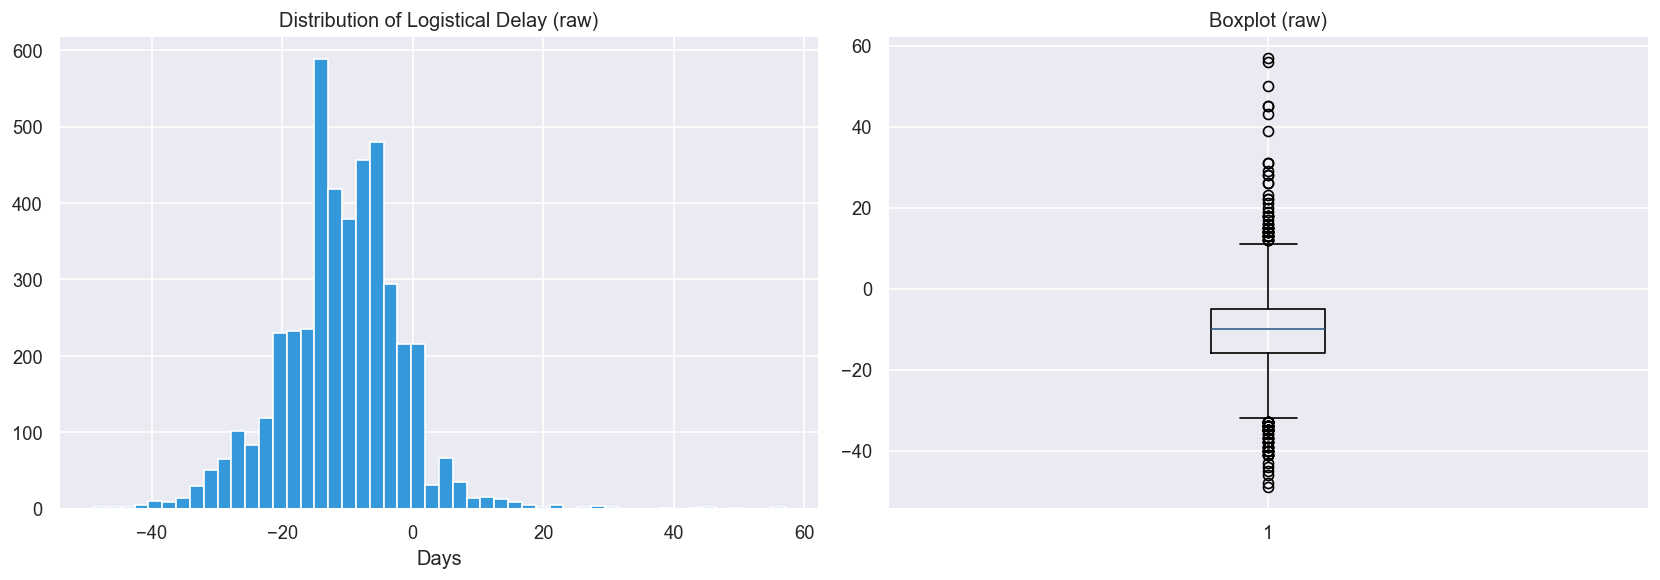


IQR bounds: [-32, 12] | Outliers: 122
Delay stats AFTER capping:
count    4441.000000
mean      -10.898671
std         8.604366
min       -32.500000
25%       -16.000000
50%       -10.000000
75%        -5.000000
max        11.500000


In [6]:
# -- Integrity Check 2: Outlier Detection for logistical_delay_days --
delay = df["logistical_delay_days"].dropna()
print(f"Delay stats BEFORE capping:")
print(delay.describe().to_string())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(delay, bins=50, color="#3498db", edgecolor="white")
axes[0].set_title("Distribution of Logistical Delay (raw)")
axes[0].set_xlabel("Days")
axes[1].boxplot(delay, vert=True)
axes[1].set_title("Boxplot (raw)")
plt.tight_layout(); plt.show()

# Cap extreme outliers using IQR method
Q1, Q3 = delay.quantile(0.25), delay.quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = ((delay < lower) | (delay > upper)).sum()
print(f"\nIQR bounds: [{lower:.0f}, {upper:.0f}] | Outliers: {outliers:,}")

df["logistical_delay_days"] = df["logistical_delay_days"].clip(lower=lower, upper=upper)
print(f"Delay stats AFTER capping:")
print(df["logistical_delay_days"].dropna().describe().to_string())

---
## 2. Target Variable -- The Failure State
Score 1-2 = **Negative Sentiment (1)** | Score 3-5 = **Acceptable (0)**

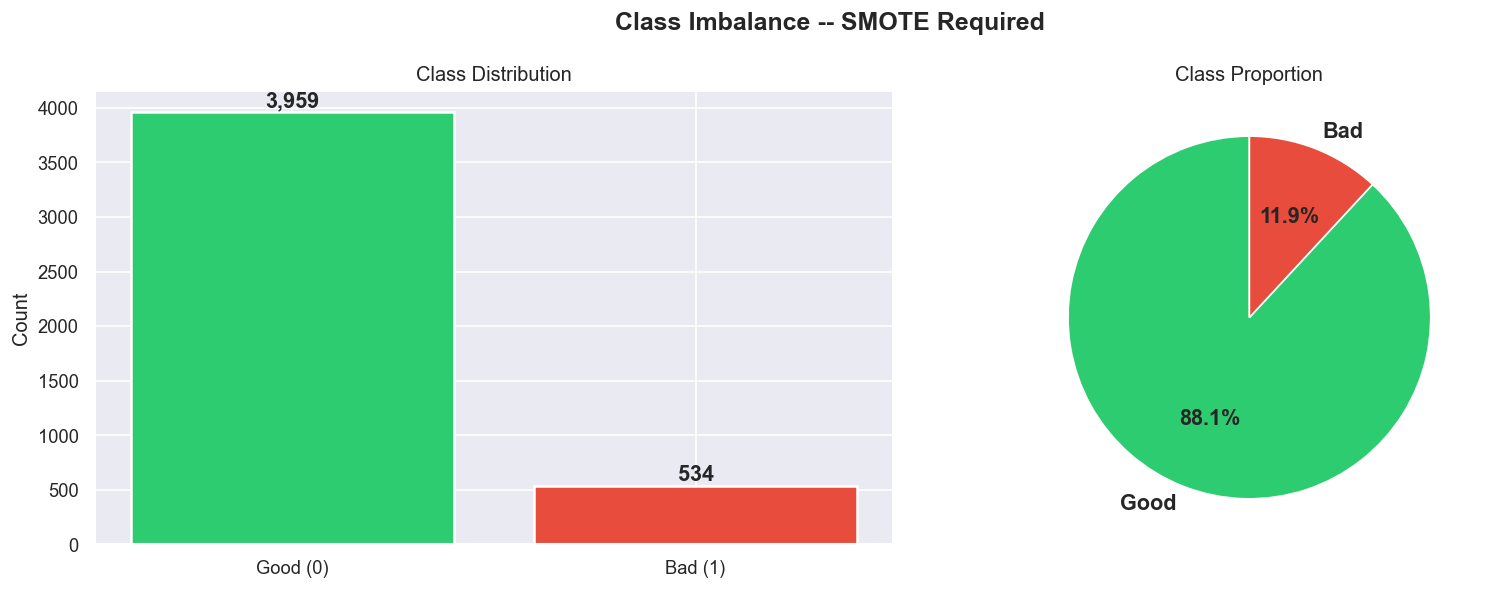

Imbalance ratio: 7.4:1


In [7]:
# Create binary target
df["is_bad_review"] = (df["final_review_score"] <= 2).astype(int)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = df["is_bad_review"].value_counts()
bars = axes[0].bar(["Good (0)", "Bad (1)"], counts.values,
                   color=["#2ecc71", "#e74c3c"], edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                 f"{val:,}", ha="center", fontweight="bold", fontsize=13)
axes[0].set_title("Class Distribution"); axes[0].set_ylabel("Count")
axes[1].pie(counts.values, labels=["Good","Bad"], autopct="%1.1f%%",
            colors=["#2ecc71","#e74c3c"], startangle=90,
            textprops={"fontsize":13,"fontweight":"bold"})
axes[1].set_title("Class Proportion")
plt.suptitle("Class Imbalance -- SMOTE Required", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()
print(f"Imbalance ratio: {counts[0]/counts[1]:.1f}:1")

---
## 3. NLP Feature Engineering -- Portuguese Text
Clean the text, remove Portuguese stopwords, then TF-IDF the top 20 negative keywords.

In [8]:
# -- Text Cleaning Pipeline --
# Download NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('rslp', quiet=True) # Portuguese stemmer

pt_stopwords = set(stopwords.words('portuguese'))
# Add domain-specific noise words that don't carry sentiment
pt_stopwords.update(['pra', 'pro', 'pq', 'produto', 'comprei', 'veio', 'chegou', 'dia'])
stemmer = RSLPStemmer()

def clean_portuguese(text):
    if not isinstance(text, str) or text.strip() == "":
        return ""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)          # remove punctuation/numbers
    tokens = text.split()
    # Stemming reduces words to their root
    tokens = [stemmer.stem(t) for t in tokens if t not in pt_stopwords and len(t) > 2]
    return " ".join(tokens)

df["review_clean"] = df["review_message"].fillna("").apply(clean_portuguese)

# How many bad reviews have text?
bad_with_text = df.loc[(df["is_bad_review"]==1) & (df["review_clean"]!="")]
print(f"Bad reviews with text: {len(bad_with_text):,} / {df['is_bad_review'].sum():,}")

# -- Fit TF-IDF on BAD reviews to discover strictly filtered negative vocabulary --
# Strict rules: min_df=0.05, max_df=0.5, exactly top 15 features
tfidf = TfidfVectorizer(max_features=15, ngram_range=(1,2), min_df=0.05,
                        max_df=0.5, sublinear_tf=True)
tfidf.fit(bad_with_text["review_clean"])

neg_keywords = tfidf.get_feature_names_out()
print(f"\n== Top 15 Highly Filtered Negative Keywords (Portuguese) ==")
for i, kw in enumerate(neg_keywords, 1):
    print(f"  {i:>2}. {kw}")

# Transform ALL reviews
tfidf_matrix = tfidf.transform(df["review_clean"])
tfidf_cols = [f"keyword_{kw.replace(' ','_')}" for kw in neg_keywords]
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_cols, index=df.index)
df = pd.concat([df, tfidf_df], axis=1)
print(f"\nAdded {len(tfidf_cols)} Strict NLP triggers")


Bad reviews with text: 413 / 534

== Top 15 Highly Filtered Negative Keywords (Portuguese) ==
   1. agor
   2. aguard
   3. aind
   4. compr
   5. entreg
   6. loj
   7. nao
   8. outr
   9. pag
  10. ped
  11. praz
  12. quer
  13. receb
  14. sit
  15. troc

Added 15 Strict NLP triggers


---
## 4. Feature Matrix, One-Hot Encoding & SMOTE
- One-Hot Encode categoricals (no fake ordinality)
- Scale numerics
- SMOTE on **training data only**

In [9]:
# -- Define columns --
ID_COLS = ["mql_id","seller_id","order_id"]
LEAK_COLS = ["final_review_score","review_message","review_clean"]
TARGET = "is_bad_review"
CAT_COLS = ["marketing_channel","business_segment"]
NUM_COLS = ["total_items_sold","total_order_revenue"]

# -- 1. Clean Channels --
# Group channels with < 50 records into 'Other'
channel_counts = df["marketing_channel"].value_counts()
df["marketing_channel"] = df["marketing_channel"].apply(lambda x: "Other" if channel_counts.get(x, 0) < 50 else x)

# Fill NaN
for c in CAT_COLS: df[c] = df[c].fillna("unknown")
for c in NUM_COLS: df[c] = df[c].fillna(df[c].median())
df["logistical_delay_days"] = df["logistical_delay_days"].fillna(df["logistical_delay_days"].median())

# -- 2. Fix the Delay Metric --
df["capped_delay_days"] = df["logistical_delay_days"].clip(lower=0)
df["revenue_at_risk"] = df["capped_delay_days"] * df["total_order_revenue"]
ENGINEERED_COLS = ["capped_delay_days", "revenue_at_risk"]
NUM_COLS_EXT = NUM_COLS + ENGINEERED_COLS
print(f"Added explicit operational metrics: {ENGINEERED_COLS}")

# -- One-Hot Encode categoricals --
ohe = OneHotEncoder(sparse_output=False, drop="first", handle_unknown="infrequent_if_exist")
ohe_matrix = ohe.fit_transform(df[CAT_COLS])
ohe_cols = ohe.get_feature_names_out(CAT_COLS).tolist()
ohe_df = pd.DataFrame(ohe_matrix, columns=ohe_cols, index=df.index)

# -- Assemble feature matrix --
feature_cols = NUM_COLS_EXT + ohe_cols + tfidf_cols
X = pd.concat([df[NUM_COLS_EXT].reset_index(drop=True),
               ohe_df.reset_index(drop=True),
               df[tfidf_cols].reset_index(drop=True)], axis=1).values
y = df[TARGET].values
print(f"Feature matrix: {X.shape} | Features: {len(feature_cols)}")

# -- Train/Test Split --
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

# -- Scale --
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# -- Class Weights --
pos_count = np.sum(y_train == 1)
neg_count = np.sum(y_train == 0)
scale_weight = neg_count / pos_count
print(f"Calculated scale_pos_weight for imbalance: {scale_weight:.2f}")

X_train_sm, y_train_sm = X_train_sc, y_train


Added explicit operational metrics: ['capped_delay_days', 'revenue_at_risk']
Feature matrix: (4493, 54) | Features: 54
Train: 3,594 | Test: 899
Calculated scale_pos_weight for imbalance: 7.42


---
## 5. Random Forest + Optuna

In [10]:
def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators",100,500,step=50),
        "max_depth": trial.suggest_int("max_depth",5,30),
        "min_samples_split": trial.suggest_int("min_samples_split",2,20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf",1,10),
        "max_features": trial.suggest_categorical("max_features",["sqrt","log2"]),
        "random_state": SEED, "n_jobs": -1, "class_weight": "balanced"
    }
    clf = RandomForestClassifier(**params)
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    scores = []
    for tr, vl in skf.split(X_train_sm, y_train_sm):
        clf.fit(X_train_sm[tr], y_train_sm[tr])
        scores.append(f1_score(y_train_sm[vl], clf.predict(X_train_sm[vl])))
    return np.mean(scores)

study_rf = optuna.create_study(direction="maximize", study_name="RF")
study_rf.optimize(objective_rf, n_trials=40, show_progress_bar=True)
print(f"Best F1: {study_rf.best_value:.4f}\nParams: {study_rf.best_params}")

rf_model = RandomForestClassifier(**study_rf.best_params, random_state=SEED, n_jobs=-1, class_weight="balanced")
rf_model.fit(X_train_sm, y_train_sm)
print("Random Forest trained.")




  0%|          | 0/40 [00:00<?, ?it/s]

Best F1: 0.6064
Params: {'n_estimators': 100, 'max_depth': 9, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
Random Forest trained.


---
## 6. XGBoost + Optuna

In [11]:
def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators",100,500,step=50),
        "max_depth": trial.suggest_int("max_depth",3,12),
        "learning_rate": trial.suggest_float("learning_rate",0.01,0.3,log=True),
        "subsample": trial.suggest_float("subsample",0.6,1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree",0.6,1.0),
        "gamma": trial.suggest_float("gamma",0,5),
        "reg_alpha": trial.suggest_float("reg_alpha",1e-4,10,log=True),
        "reg_lambda": trial.suggest_float("reg_lambda",1e-4,10,log=True),
        "eval_metric":"logloss", "scale_pos_weight": scale_weight,"random_state":SEED,"n_jobs":-1
    }
    clf = xgb.XGBClassifier(**params)
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    scores = []
    for tr, vl in skf.split(X_train_sm, y_train_sm):
        clf.fit(X_train_sm[tr], y_train_sm[tr])
        scores.append(f1_score(y_train_sm[vl], clf.predict(X_train_sm[vl])))
    return np.mean(scores)

study_xgb = optuna.create_study(direction="maximize", study_name="XGB")
study_xgb.optimize(objective_xgb, n_trials=40, show_progress_bar=True)
print(f"Best F1: {study_xgb.best_value:.4f}\nParams: {study_xgb.best_params}")

xgb_model = xgb.XGBClassifier(**study_xgb.best_params, eval_metric="logloss", scale_pos_weight=scale_weight,
                                random_state=SEED, n_jobs=-1)
xgb_model.fit(X_train_sm, y_train_sm)
print("XGBoost trained.")




  0%|          | 0/40 [00:00<?, ?it/s]

Best F1: 0.5864
Params: {'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.011008372216939882, 'subsample': 0.7468355028558271, 'colsample_bytree': 0.6085862046791742, 'gamma': 3.0162738150561266, 'reg_alpha': 0.0010641411607777095, 'reg_lambda': 0.0014098050520832293}
XGBoost trained.


---
## 7. LightGBM + Optuna
> LightGBM is highly efficient for tabular data and handles sparse data (like TF-IDF) extremely well.

In [12]:
def objective_lgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators",100,500,step=50),
        "max_depth": trial.suggest_int("max_depth",3,15),
        "num_leaves": trial.suggest_int("num_leaves",20,150),
        "learning_rate": trial.suggest_float("learning_rate",0.01,0.3,log=True),
        "subsample": trial.suggest_float("subsample",0.6,1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree",0.6,1.0),
        "reg_alpha": trial.suggest_float("reg_alpha",1e-4,10,log=True),
        "reg_lambda": trial.suggest_float("reg_lambda",1e-4,10,log=True),
        "random_state":SEED, "scale_pos_weight": scale_weight, "n_jobs":-1, "verbose":-1
    }
    clf = lgb.LGBMClassifier(**params)
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    scores = []
    for tr, vl in skf.split(X_train_sm, y_train_sm):
        clf.fit(X_train_sm[tr], y_train_sm[tr])
        scores.append(f1_score(y_train_sm[vl], clf.predict(X_train_sm[vl])))
    return np.mean(scores)

study_lgb = optuna.create_study(direction="maximize", study_name="LGBM")
study_lgb.optimize(objective_lgb, n_trials=40, show_progress_bar=True)
print(f"Best F1: {study_lgb.best_value:.4f}\nParams: {study_lgb.best_params}")

lgb_model = lgb.LGBMClassifier(**study_lgb.best_params, random_state=SEED, scale_pos_weight=scale_weight, n_jobs=-1, verbose=-1)
lgb_model.fit(X_train_sm, y_train_sm)
print("LightGBM trained.")




  0%|          | 0/40 [00:00<?, ?it/s]

Best F1: 0.5659
Params: {'n_estimators': 250, 'max_depth': 11, 'num_leaves': 84, 'learning_rate': 0.010536809919228642, 'subsample': 0.8666111805859803, 'colsample_bytree': 0.9711659764714261, 'reg_alpha': 0.007713034781250312, 'reg_lambda': 2.687420774327706}
LightGBM trained.


---
## 8. Model Comparison
> *Do NOT look at Accuracy. Evaluate on Recall and Precision for the minority (Bad) class.*

Ensemble optimal threshold: 0.686

  Random Forest (Threshold: 0.582)
              precision    recall  f1-score   support

        Good       0.94      0.95      0.95       792
         Bad       0.64      0.59      0.61       107

    accuracy                           0.91       899
   macro avg       0.79      0.77      0.78       899
weighted avg       0.91      0.91      0.91       899


  XGBoost (Threshold: 0.767)
              precision    recall  f1-score   support

        Good       0.94      0.97      0.96       792
         Bad       0.73      0.55      0.63       107

    accuracy                           0.92       899
   macro avg       0.83      0.76      0.79       899
weighted avg       0.92      0.92      0.92       899


  LightGBM (Threshold: 0.585)
              precision    recall  f1-score   support

        Good       0.95      0.94      0.95       792
         Bad       0.59      0.63      0.61       107

    accuracy                           0.90       8

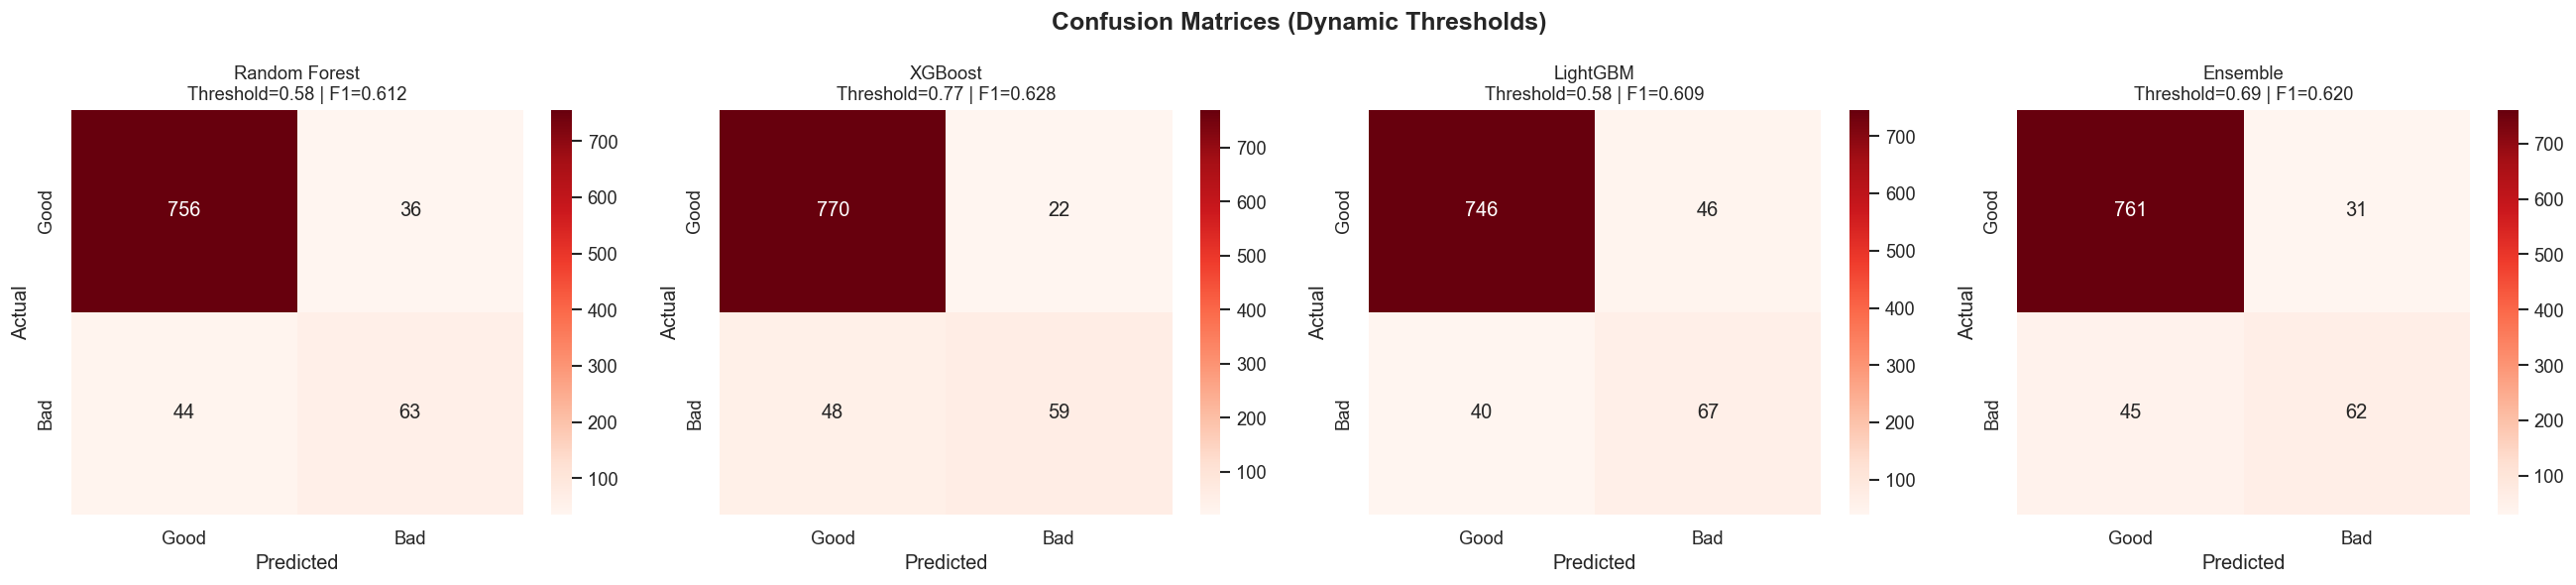

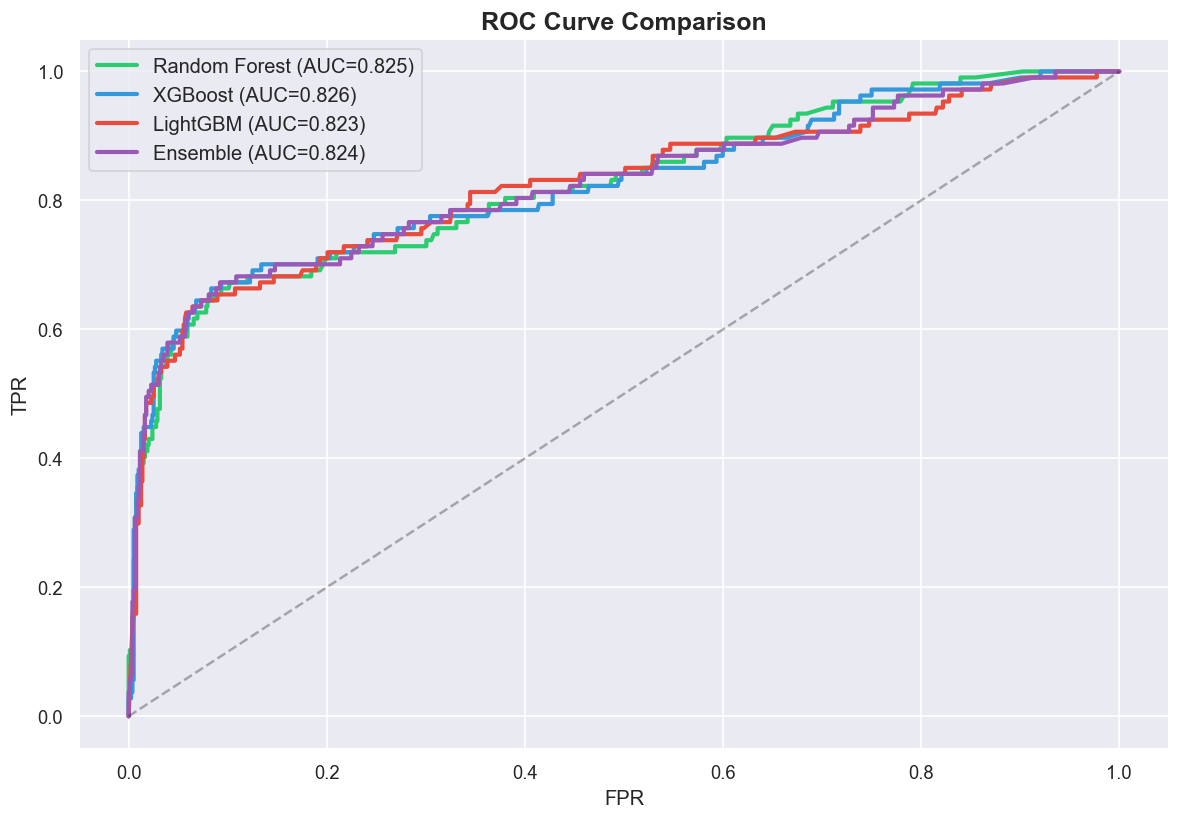


== Model Leaderboard (sorted by Bad-class Recall) ==
        Model Threshold     F1    AUC Bad_Recall Bad_Precision
     LightGBM      0.58 0.6091 0.8230     0.6262        0.5929
Random Forest      0.58 0.6117 0.8248     0.5888        0.6364
     Ensemble      0.69 0.6200 0.8240     0.5794        0.6667
      XGBoost      0.77 0.6277 0.8256     0.5514        0.7284


In [13]:
from sklearn.metrics import precision_recall_curve

# ---- Individual Model Predictions with Dynamic Thresholding ----
y_preds, y_probas, best_thresholds = {}, {}, {}

for name, mdl in [("Random Forest",rf_model), ("XGBoost",xgb_model), ("LightGBM",lgb_model)]:
    proba = mdl.predict_proba(X_test_sc)[:,1]
    y_probas[name] = proba
    precisions, recalls, thresholds = precision_recall_curve(y_test, proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    best_thresholds[name] = best_thresh
    y_preds[name] = (proba >= best_thresh).astype(int)

# ---- Soft Voting Ensemble ----
# Average probabilities from all 3 models
ensemble_proba = (y_probas["Random Forest"] + y_probas["XGBoost"] + y_probas["LightGBM"]) / 3
y_probas["Ensemble"] = ensemble_proba
precisions, recalls, thresholds = precision_recall_curve(y_test, ensemble_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
best_thresh_ens = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
best_thresholds["Ensemble"] = best_thresh_ens
y_preds["Ensemble"] = (ensemble_proba >= best_thresh_ens).astype(int)
print(f"Ensemble optimal threshold: {best_thresh_ens:.3f}")

# ---- Classification Reports ----
for name in y_preds:
    print(f"\n{'='*55}\n  {name} (Threshold: {best_thresholds[name]:.3f})\n{'='*55}")
    print(classification_report(y_test, y_preds[name], target_names=["Good","Bad"]))

# ---- Confusion Matrices ----
fig, axes = plt.subplots(1,4,figsize=(22,5))
for ax, name in zip(axes, y_preds):
    cm = confusion_matrix(y_test, y_preds[name])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", ax=ax,
                xticklabels=["Good","Bad"], yticklabels=["Good","Bad"])
    f1 = f1_score(y_test, y_preds[name])
    ax.set_title(f"{name}\nThreshold={best_thresholds[name]:.2f} | F1={f1:.3f}", fontsize=11)
    ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")
plt.suptitle("Confusion Matrices (Dynamic Thresholds)", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()

# ---- ROC Curves ----
fig, ax = plt.subplots(figsize=(10,7))
colors = ["#2ecc71","#3498db","#e74c3c","#9b59b6"]
for (name,proba),color in zip(y_probas.items(), colors):
    fpr,tpr,_ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test,proba):.3f})",
            color=color, linewidth=2.5)
ax.plot([0,1],[0,1],"k--",alpha=0.3)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC Curve Comparison", fontsize=15, fontweight="bold")
ax.legend(fontsize=12); plt.tight_layout(); plt.show()

# ---- Leaderboard ----
rows = []
for name in y_preds:
    f1 = f1_score(y_test, y_preds[name])
    auc = roc_auc_score(y_test, y_probas[name])
    cr = classification_report(y_test, y_preds[name], target_names=["Good","Bad"], output_dict=True)
    rows.append({"Model":name, "Threshold": f"{best_thresholds[name]:.2f}",
                 "F1":f"{f1:.4f}", "AUC":f"{auc:.4f}",
                 "Bad_Recall":f"{cr['Bad']['recall']:.4f}",
                 "Bad_Precision":f"{cr['Bad']['precision']:.4f}"})
leaderboard = pd.DataFrame(rows).sort_values("Bad_Recall",ascending=False)
print("\n== Model Leaderboard (sorted by Bad-class Recall) ==")
print(leaderboard.to_string(index=False))


---
## 9. Feature Importance & SHAP

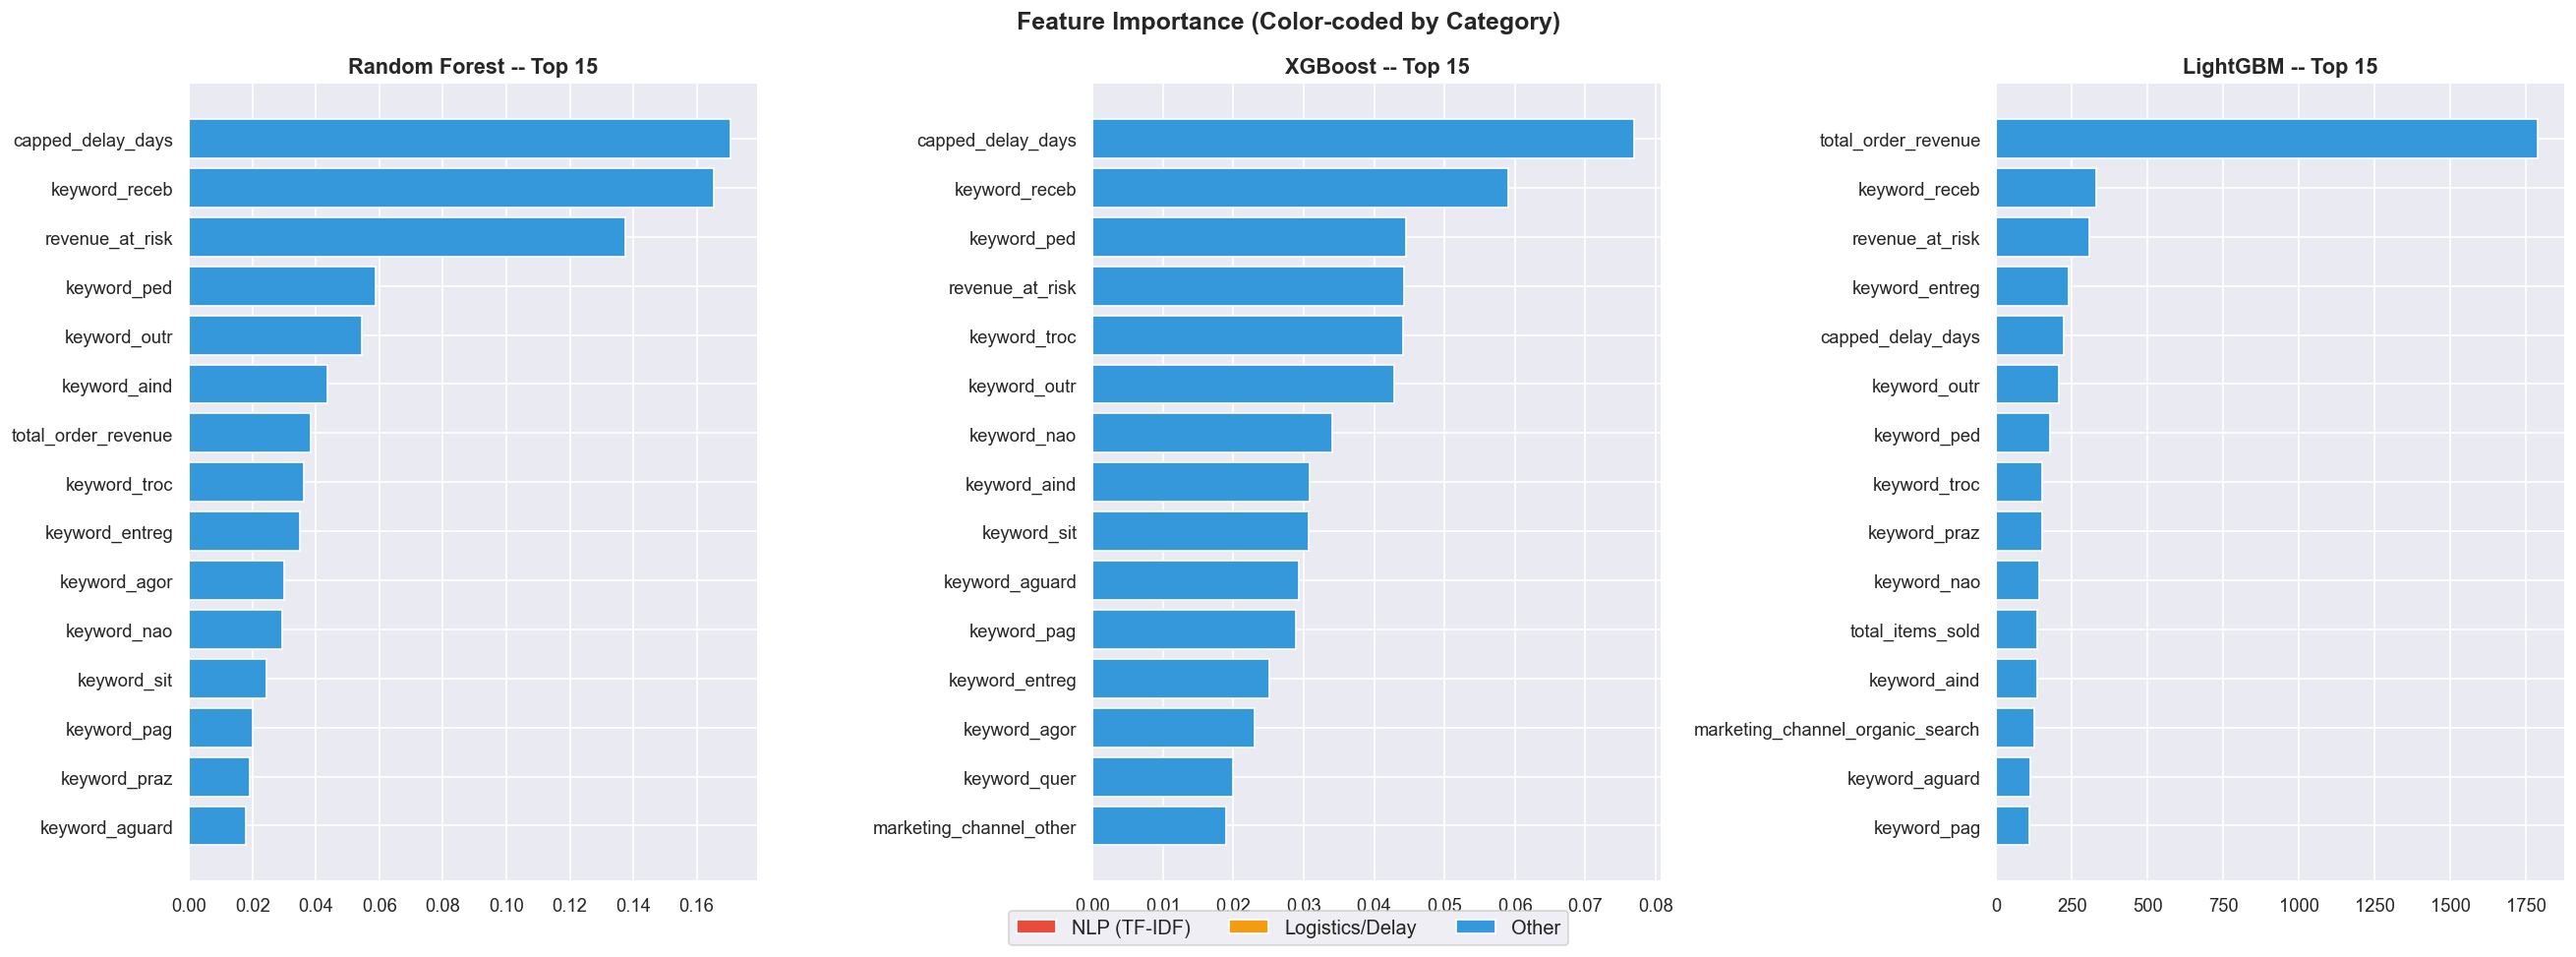

In [14]:
# RF vs XGB vs LGBM Feature Importance
fig, axes = plt.subplots(1,3,figsize=(22,8))
for ax, (name,mdl) in zip(axes, [("Random Forest",rf_model), ("XGBoost",xgb_model), ("LightGBM",lgb_model)]):
    imp = mdl.feature_importances_
    idx = np.argsort(imp)[-15:]
    colors = ["#e74c3c" if feature_cols[i].startswith("word_") else
              "#f39c12" if feature_cols[i].startswith("delay") or feature_cols[i] == "is_late" else
              "#3498db" for i in idx]
    ax.barh(range(len(idx)), imp[idx], color=colors, edgecolor="white")
    ax.set_yticks(range(len(idx)))
    ax.set_yticklabels([feature_cols[i] for i in idx])
    ax.set_title(f"{name} -- Top 15", fontsize=13, fontweight="bold")

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#e74c3c", label="NLP (TF-IDF)"),
                   Patch(facecolor="#f39c12", label="Logistics/Delay"),
                   Patch(facecolor="#3498db", label="Other")]
fig.legend(handles=legend_elements, loc="lower center", ncol=3, fontsize=12,
           bbox_to_anchor=(0.5, -0.02))
plt.suptitle("Feature Importance (Color-coded by Category)", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()


Computing SHAP values for LightGBM...

--- 1. SHAP Beeswarm Plot ---


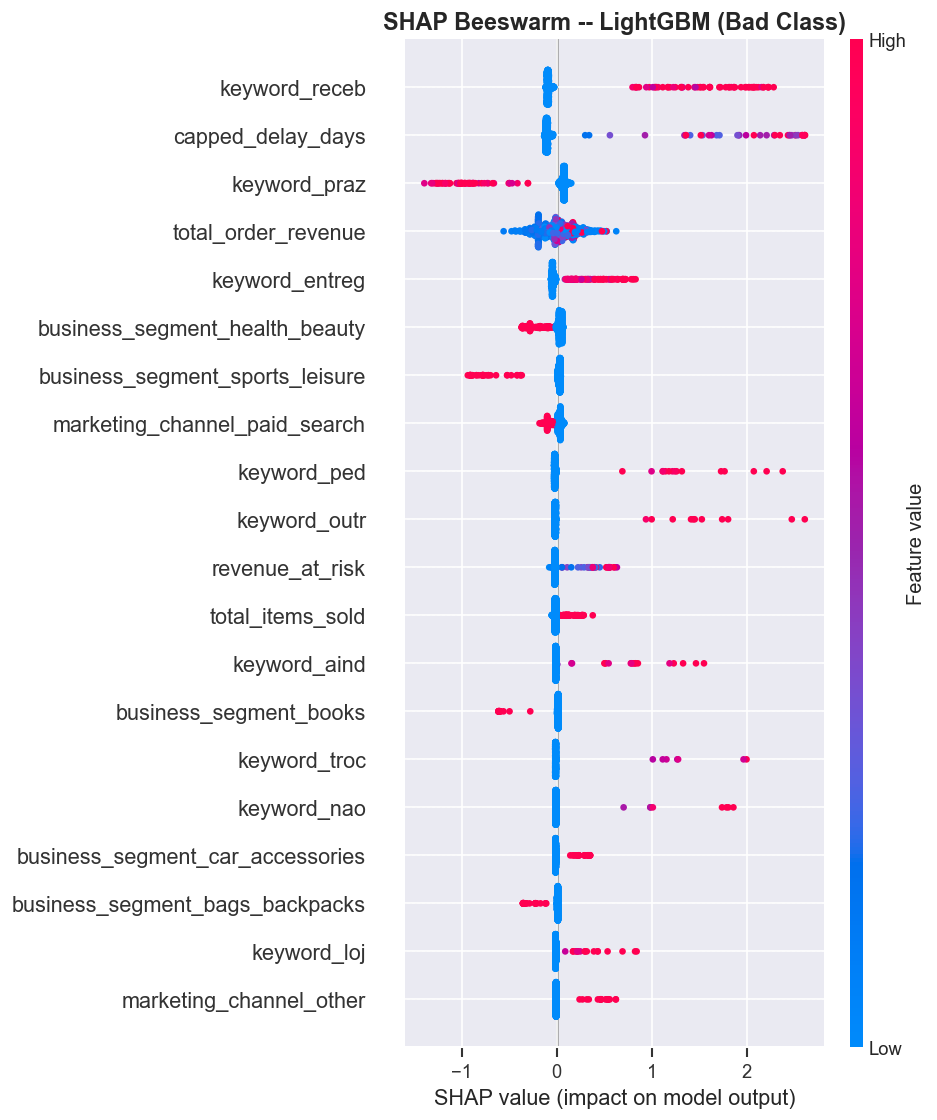


--- 2. SHAP Bar Plot (Global Feature Importance) ---


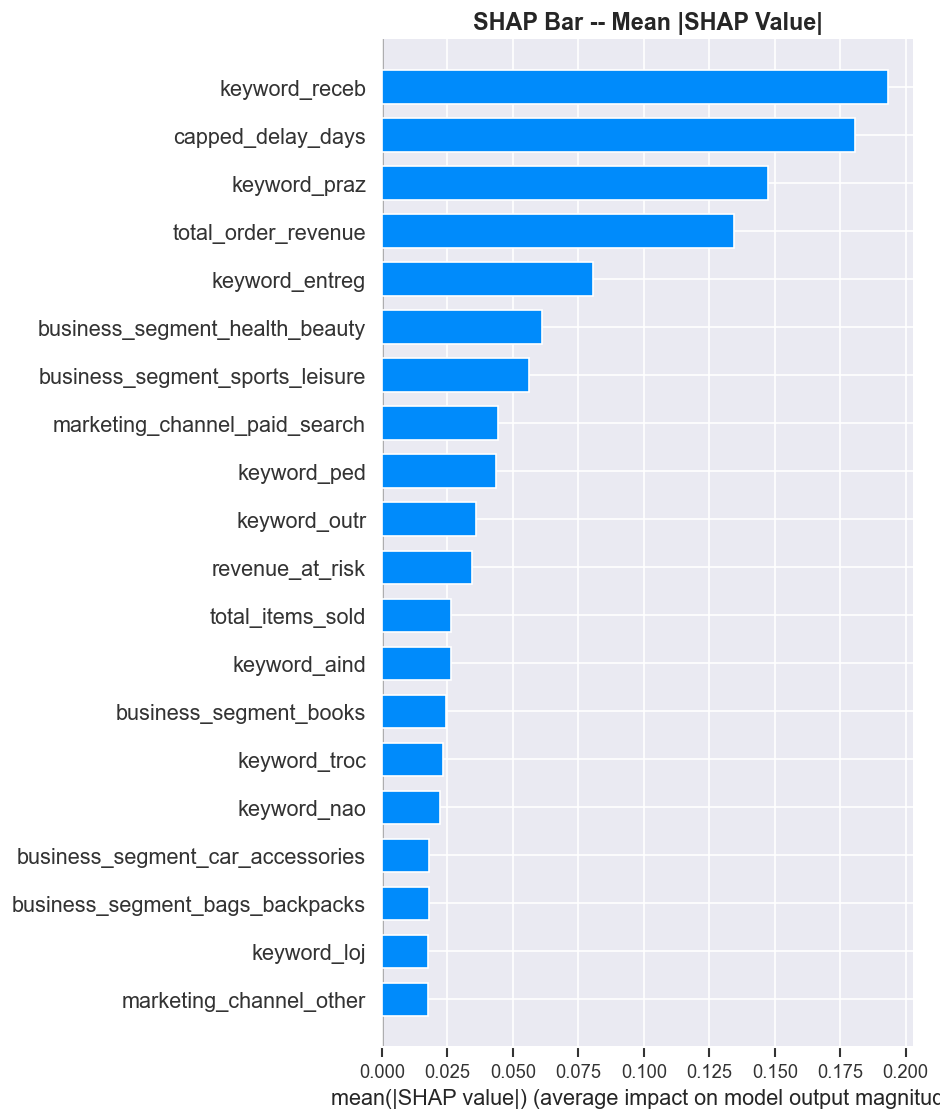


--- 3. SHAP Waterfall Plot (A Sample Bad Review) ---


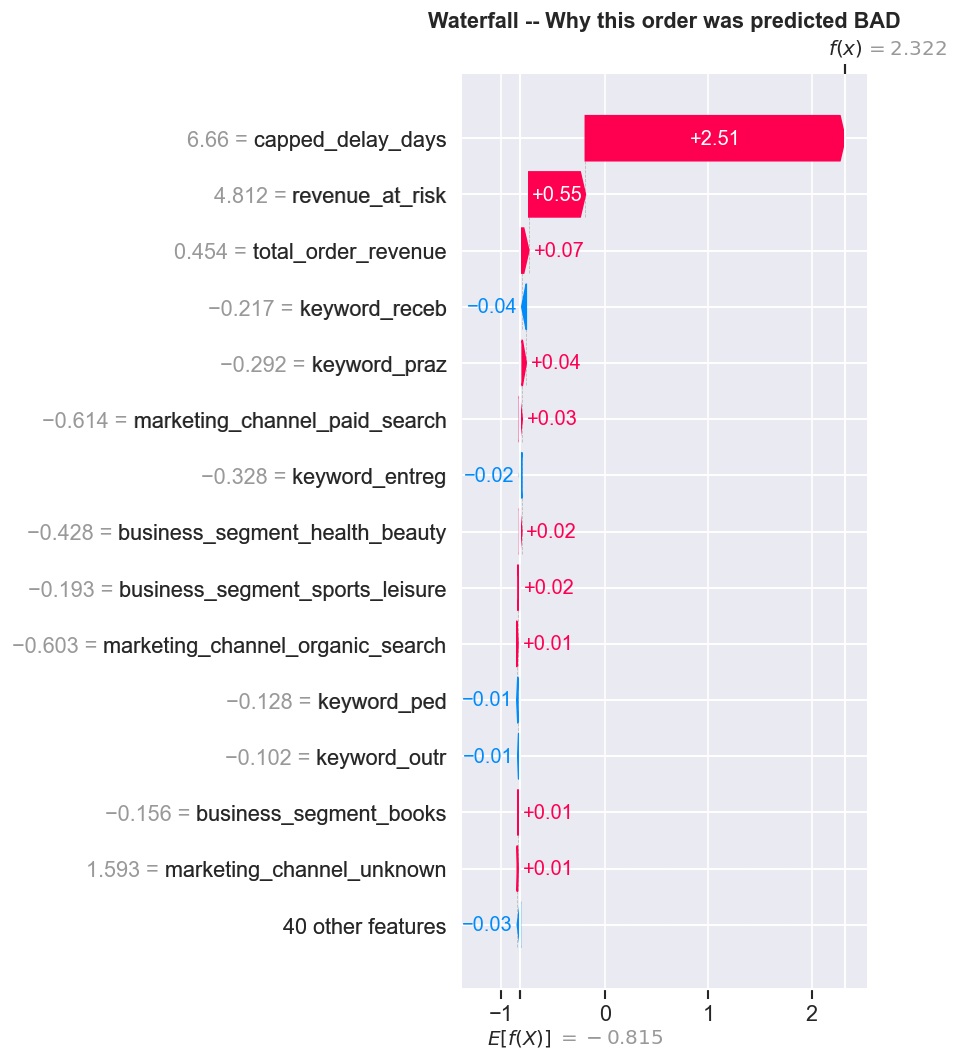


--- 4. SHAP Dependence Plots ---

--- 5. SHAP Heatmap ---


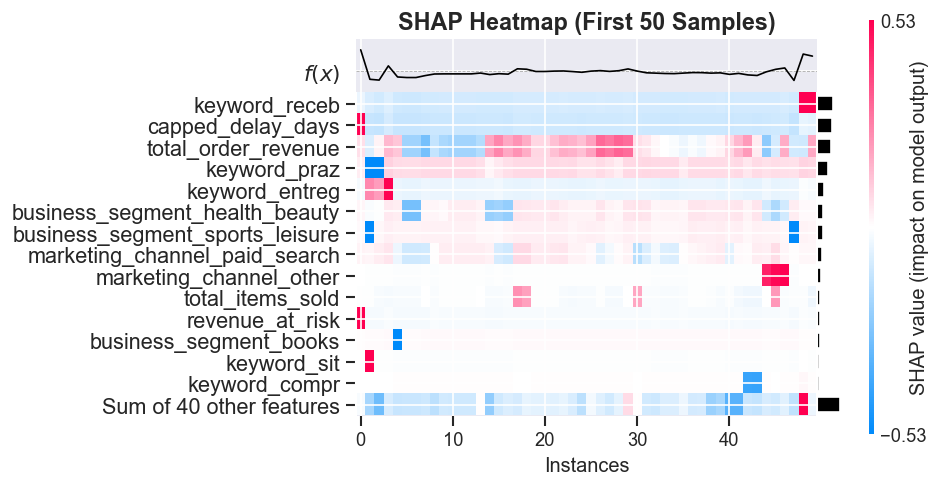


SHAP analysis complete!


In [15]:
# ---- SHAP Explainability (LightGBM) ----
print("Computing SHAP values for LightGBM...")
explainer = shap.TreeExplainer(lgb_model)
shap_vals = explainer.shap_values(X_test_sc)

# If shap_vals is a list (binary classification), take class 1 (Bad)
if isinstance(shap_vals, list):
    shap_vals_bad = shap_vals[1]
else:
    shap_vals_bad = shap_vals

# 1. Beeswarm Plot
print("\n--- 1. SHAP Beeswarm Plot ---")
plt.figure(figsize=(12,8))
shap.summary_plot(shap_vals_bad, X_test_sc, feature_names=feature_cols,
                  max_display=20, show=False)
plt.title("SHAP Beeswarm -- LightGBM (Bad Class)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

# 2. Bar Plot (Mean |SHAP|)
print("\n--- 2. SHAP Bar Plot (Global Feature Importance) ---")
plt.figure(figsize=(12,6))
shap.summary_plot(shap_vals_bad, X_test_sc, feature_names=feature_cols,
                  plot_type="bar", max_display=20, show=False)
plt.title("SHAP Bar -- Mean |SHAP Value|", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

# 3. Waterfall Plot (Single Prediction Explanation)
print("\n--- 3. SHAP Waterfall Plot (A Sample Bad Review) ---")
bad_indices = np.where(y_test == 1)[0]
if len(bad_indices) > 0:
    sample_idx = bad_indices[0]  # Pick the first bad review
    expl = shap.Explanation(
        values=shap_vals_bad[sample_idx],
        base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
        data=X_test_sc[sample_idx],
        feature_names=feature_cols
    )
    plt.figure(figsize=(12,8))
    shap.plots.waterfall(expl, max_display=15, show=False)
    plt.title("Waterfall -- Why this order was predicted BAD", fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()

# 4. Dependence Plot (logistical_delay_days)
print("\n--- 4. SHAP Dependence Plots ---")
# Find the index of logistical_delay_days in feature_cols
if "logistical_delay_days" in feature_cols:
    delay_idx = feature_cols.index("logistical_delay_days")
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    plt.sca(axes[0])
    shap.dependence_plot(delay_idx, shap_vals_bad, X_test_sc,
                         feature_names=feature_cols, show=False, ax=axes[0])
    axes[0].set_title("Dependence: logistical_delay_days", fontsize=12, fontweight="bold")
    
    # Also do revenue
    if "total_order_revenue" in feature_cols:
        rev_idx = feature_cols.index("total_order_revenue")
        plt.sca(axes[1])
        shap.dependence_plot(rev_idx, shap_vals_bad, X_test_sc,
                             feature_names=feature_cols, show=False, ax=axes[1])
        axes[1].set_title("Dependence: total_order_revenue", fontsize=12, fontweight="bold")
    plt.suptitle("SHAP Dependence Plots", fontsize=15, fontweight="bold")
    plt.tight_layout(); plt.show()

# 5. Heatmap (if shap version supports it)
print("\n--- 5. SHAP Heatmap ---")
try:
    expl_all = shap.Explanation(
        values=shap_vals_bad[:50],  # First 50 samples for readability
        base_values=np.full(50, explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value),
        data=X_test_sc[:50],
        feature_names=feature_cols
    )
    plt.figure(figsize=(16,8))
    shap.plots.heatmap(expl_all, max_display=15, show=False)
    plt.title("SHAP Heatmap (First 50 Samples)", fontsize=14, fontweight="bold")
    plt.tight_layout(); plt.show()
except Exception as e:
    print(f"Heatmap skipped (shap version may not support it): {e}")

print("\nSHAP analysis complete!")


---
## 10. Final Export for Tableau
Curated CSV merging seller channels, delay times, review scores, NLP keywords, and model predictions.

In [16]:
# -- The Final Dashboard Export --

# 1. Calculate final predictions using the ensemble logic
X_all = pd.concat([df[NUM_COLS_EXT].reset_index(drop=True),
                   ohe_df.reset_index(drop=True),
                   df[tfidf_cols].reset_index(drop=True)], axis=1).values
X_all_sc = scaler.transform(X_all)

best_name = leaderboard.iloc[0]["Model"]
best_thresh = best_thresholds[best_name]

if best_name == "Ensemble":
    prob_rf = rf_model.predict_proba(X_all_sc)[:,1]
    prob_xgb = xgb_model.predict_proba(X_all_sc)[:,1]
    prob_lgb = lgb_model.predict_proba(X_all_sc)[:,1]
    final_prob = (prob_rf + prob_xgb + prob_lgb) / 3
else:
    model_map = {"Random Forest": rf_model, "XGBoost": xgb_model, "LightGBM": lgb_model}
    final_prob = model_map[best_name].predict_proba(X_all_sc)[:,1]

df["predicted_bad"] = (final_prob >= best_thresh).astype(int)
df["actual_review_score"] = df["final_review_score"]

# 2. Convert NLP floats to STRICT binary 1 or 0
for kw_col in tfidf_cols:
    df[kw_col] = (df[kw_col] > 0).astype(int)

# 3. Enforce strictly defined columns
dashboard_columns = [
    # Dimensions
    "order_id",
    "seller_id",
    "marketing_channel",
    "business_segment",
    # Hard Metrics
    "total_items_sold",
    "total_order_revenue",
    "capped_delay_days",
    "revenue_at_risk",
    # Sentiment
    "actual_review_score",
    "predicted_bad"
] + tfidf_cols  # The top 15 keyword_* features

df_final = df[dashboard_columns].copy()

# Save precisely formatted dataset
OUT = Path("Dataset/final_dashboard_data.csv")
df_final.to_csv(OUT, index=False, encoding="utf-8-sig", float_format="%.2f", sep=",")
print(f"\n=== DASHBOARD EXPORT SUCCESS ===")
print(f"File: {OUT}")
print(f"Rows: {len(df_final):,}")
print(f"Columns: {df_final.columns.tolist()}")


OUT = Path("Dataset/final_dashboard_data.xlsx")
OUT.parent.mkdir(parents=True, exist_ok=True)

with pd.ExcelWriter(OUT, engine="xlsxwriter") as writer:
    df_final.to_excel(writer, index=False, sheet_name="data")

df_final.head()


=== DASHBOARD EXPORT SUCCESS ===
File: Dataset\final_dashboard_data.csv
Rows: 4,493
Columns: ['order_id', 'seller_id', 'marketing_channel', 'business_segment', 'total_items_sold', 'total_order_revenue', 'capped_delay_days', 'revenue_at_risk', 'actual_review_score', 'predicted_bad', 'keyword_agor', 'keyword_aguard', 'keyword_aind', 'keyword_compr', 'keyword_entreg', 'keyword_loj', 'keyword_nao', 'keyword_outr', 'keyword_pag', 'keyword_ped', 'keyword_praz', 'keyword_quer', 'keyword_receb', 'keyword_sit', 'keyword_troc']


,order_id,seller_id,marketing_channel,business_segment,total_items_sold,total_order_revenue,capped_delay_days,revenue_at_risk,actual_review_score,predicted_bad,...,keyword_loj,keyword_nao,keyword_outr,keyword_pag,keyword_ped,keyword_praz,keyword_quer,keyword_receb,keyword_sit,keyword_troc
0,0005f50442cb953dcd1d21e1fb923495,ba143b05f0110f0dc71ad71b4466ce92,paid_search,books,1.0,53.99,0.0,0.0,4.0,0,...,0,0,0,0,0,0,0,0,0,0
1,001ac194d4a326a6fa99b581e9a3d963,ffc470761de7d0232558ba5e786e57b7,unknown,construction_tools_house_garden,1.0,54.00,0.0,0.0,5.0,0,...,0,0,0,0,0,1,0,0,0,0
2,0029f17cf0e7640c5cb6825af681303f,d3dcf0604eabf0224fbd5948b5e02f69,unknown,music_instruments,1.0,94.90,0.0,0.0,5.0,0,...,0,0,0,0,0,0,0,0,0,0
3,00335f75ea6a4455b524a8dd177067f5,70c27847eca8195c983ed7e798c56743,social,pet,1.0,168.80,0.0,0.0,5.0,0,...,0,0,0,0,0,0,0,0,0,0
4,00345f338696283410b7977d2e3efc89,516e7738bd8f735ac19a010ee5450d8d,paid_search,health_beauty,1.0,48.90,0.0,0.0,5.0,0,...,0,0,0,0,0,0,0,0,0,0


---
## Key Findings
1. **`logistical_delay_days`** -- If dominant, late deliveries directly cause bad reviews (operational problem)
2. **`marketing_channel`** -- High-importance channels are sourcing low-quality sellers
3. **`word_*` TF-IDF features** -- Reveal what customers complain about (delay, broken, etc.)
4. **Model choice** -- Use the model with best **Recall on Bad class** (catching real bad reviews matters more than avoiding false alarms)